In [1]:
import pandas as pd

In [2]:
comments = pd.read_parquet('/Users/emma/Desktop/thesis/actual_folder/clean/total_comments_B.parquet')

In [3]:
subs = pd.read_parquet("/Users/emma/Desktop/politics_submissions/part-00000-3c8f5bcf-faf2-42e7-a356-d77f75747eff-c000.snappy.parquet")

subs['subreddit'] = 'politics'

In [4]:
cons = pd.read_parquet("/Users/emma/Desktop/cons_submissions/part-00000-c6c5c904-2ffe-4b0e-be27-236d4a5abac2-c000.snappy.parquet")

cons['subreddit'] = 'conservative'

subs = pd.concat([subs, cons]).reset_index(drop=True)

In [5]:
subs[subs['id'] == 'vjpng8']

,title,author,id,link_flair_text,url,time,subreddit,created_utc
28692,Megathread: Supreme Court overturns Roe v. Wade,PoliticsModeratorBot,vjpng8,Megathread,https://www.reddit.com/r/politics/comments/vjp...,2022-06-24 14:24:21,politics,NaN


In [6]:
pd.set_option('max_colwidth', None)

In [7]:
comments.shape

(2486416, 9)

In [8]:
comments['link_id'].value_counts()[:10]

link_id
t3_vjpng8    34876
t3_uh61gv    24697
t3_bos01u    21184
t3_uh402c    10064
t3_w4eoa4     9778
t3_vjuvlk     8447
t3_uo14t5     7927
t3_uhgdek     7656
t3_uiuqjy     7271
t3_pghh91     6654
Name: count, dtype: int64

In [9]:
top_posts = ["vjpng8", "uh61gv", "bos01u", "uh402c", "w4eoa4", "vjuvlk", "uo14t5", "uhgdek", "uiuqjy", "pghh91"]

top = subs[subs['id'].isin(top_posts)]


In [10]:
top[['title', 'time', 'subreddit']]

,title,time,subreddit
20384,Megathread: Alabama Senate Votes to Effectively Ban Abortion in the State,2019-05-15 02:15:16,politics
25106,Texans are trolling an anonymous tip line for reporting suspected abortions,2021-09-02 13:04:28,politics
26998,"Supreme Court has voted to overturn abortion rights, draft opinion shows",2022-05-03 00:37:24,politics
27069,Megathread: Draft memo shows the Supreme Court has voted to overturn Roe V Wade,2022-05-03 02:26:32,politics
27113,Biden urges Congress to codify Roe v. Wade into law,2022-05-03 13:41:27,politics
27420,Republicans Suddenly Don't Want To Talk About Banning Abortion,2022-05-05 10:48:00,politics
28044,"Biden predicts that if Supreme Court overturns Roe v. Wade, same-sex marriage will be next",2022-05-12 13:29:59,politics
28692,Megathread: Supreme Court overturns Roe v. Wade,2022-06-24 14:24:21,politics
28834,House Democrats called ‘f***ing useless’ for singing ‘God Bless America’ by Capitol after Roe ruling,2022-06-24 18:20:04,politics
30705,How in God's name are the Democrats still losing — even after Jan. 6 hearings and Roe? Headlines of the last two months should give Democrats a fighting chance in the midterms. Do they know how to win?,2022-07-21 11:48:27,politics


In [11]:
comments['time'] = pd.to_datetime(comments['time'])
comments['year'] = comments['time'].dt.year


In [12]:
comments_PY = comments['year'].value_counts().reset_index()

comments_PY

,year,count
0,2022,938902
1,2021,269482
2,2023,210403
3,2019,210055
4,2024,153700
5,2018,114448
6,2020,101475
7,2012,85022
8,2016,78908
9,2017,68398


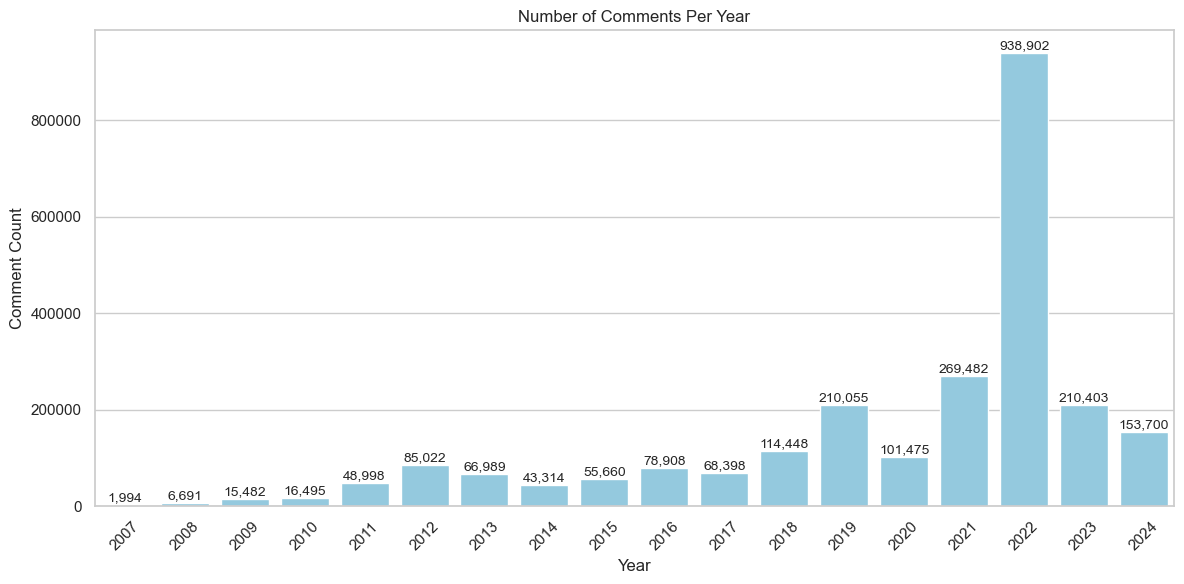

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

comments_PY.columns = ['year', 'comment_count']

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=comments_PY, x='year', y='comment_count', color='skyblue')

for bar in ax.patches:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2
    plt.text(x, height + 2000, f"{int(height):,}", ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45)
plt.title("Number of Comments Per Year")
plt.xlabel("Year")
plt.ylabel("Comment Count")
plt.tight_layout()


plt.show()



In [22]:
ysc = comments.groupby(['year', 'subreddit']).size().unstack(fill_value=0).reset_index()
ysc

subreddit,year,Conservative,politics
0,2007,0,1994
1,2008,5,6686
2,2009,13,15469
3,2010,77,16418
4,2011,286,48712
5,2012,2767,82255
6,2013,3075,63914
7,2014,1472,41842
8,2015,2341,53319
9,2016,5629,73279


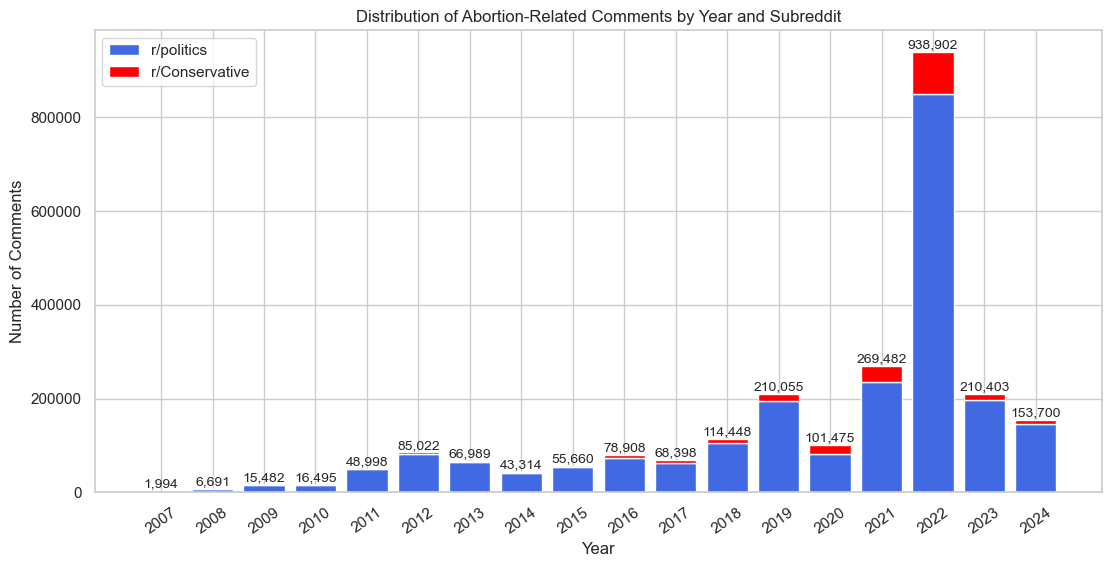

In [27]:
plt.figure(figsize = (13, 6))

plt.bar(ysc['year'], ysc['politics'], label = 'r/politics', color = 'royalblue')

ax = plt.bar(ysc['year'], ysc['Conservative'],
             bottom = ysc['politics'], label = 'r/Conservative', color = 'Red')

plt.xticks(ticks = ysc['year'], labels = ysc['year'], rotation = 35)
plt.xlabel('Year')
plt.ylabel('Number of Comments')
plt.title("Distribution of Abortion-Related Comments by Year and Subreddit")

for i, b in enumerate(ax.patches):
    politics = ysc['politics'].iloc[i]
    cons = b.get_height()
    total = politics + cons
    x = b.get_x() + b.get_width() / 2
    plt.text(x, total + 2000, f"{int(total):,}", ha='center', va='bottom', fontsize=10)

plt.legend()
plt.show()